<a href="https://colab.research.google.com/github/Dani2003/Abari1424/blob/main/Implementation_of_Training_Algorithm_for_Regression_Trees_with_Linear_Leaves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# [CELL 1 - Environment & Dependency Setup]

import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Union
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set seed for reproducible benchmark execution
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Dependencies loaded successfully. TAO Fast SMW benchmark environment initialized.")

Dependencies loaded successfully. TAO Fast SMW benchmark environment initialized.


In [5]:
# [CELL 2 - High-Dimensional Non-Linear Synthetic Data Generation]

def generate_highdim_regression_dataset(
    n_samples: int = 2000,
    n_features: int = 500,
    n_informative: int = 50,
    noise: float = 0.1,
    seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Generates high-dimensional data (D >> N_leaf at deep nodes) with piece-wise
    linear structure to test Tree Alternating Optimization (TAO).
    """
    np.random.seed(seed)
    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        noise=noise,
        random_state=seed
    )

    # Introduce piece-wise non-linearity to reward tree partitioning
    partition_mask = X[:, 0] > 0
    y[partition_mask] += 2.0 * np.sin(X[partition_mask, 1] * 3.0) + 5.0
    y[~partition_mask] -= 2.0 * np.cos(X[~partition_mask, 2] * 3.0) - 3.0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = generate_highdim_regression_dataset(n_samples=2000, n_features=500)
print(f"Dataset generated: Train samples N={X_train.shape[0]}, Features D={X_train.shape[1]}")

Dataset generated: Train samples N=1600, Features D=500


In [6]:
# [CELL 3 - Primal vs. SMW Dual Ridge Leaf Solvers]

class LeafRidgeSolver:
    """
    Implements standard Primal Ridge Regression vs. Sherman-Morrison-Woodbury (SMW)
    Dual Ridge Regression for regression tree leaves.

    Primal Ridge: w = (X^T X + \lambda I_D)^(-1) X^T y  --> O(N_m D^2 + D^3)
    SMW Dual Ridge: w = X^T (X X^T + \lambda I_{N_m})^(-1) y --> O(N_m^2 D + N_m^3)
    """
    @staticmethod
    def solve_primal(X_m: np.ndarray, y_m: np.ndarray, lmbda: float = 1e-3) -> np.ndarray:
        N_m, D = X_m.shape
        X_aug = np.hstack([X_m, np.ones((N_m, 1))]) # Include bias term
        D_aug = D + 1

        # O(N_m D^2 + D^3) computation
        A = X_aug.T @ X_aug + lmbda * np.eye(D_aug)
        b = X_aug.T @ y_m
        w_aug = np.linalg.solve(A, b)
        return w_aug

    @staticmethod
    def solve_smw_dual(X_m: np.ndarray, y_m: np.ndarray, lmbda: float = 1e-3) -> np.ndarray:
        N_m, D = X_m.shape
        X_aug = np.hstack([X_m, np.ones((N_m, 1))]) # Include bias term

        # O(N_m^2 D + N_m^3) computation using SMW dual identity
        # (X^T X + \lambda I_D)^(-1) X^T y = X^T (X X^T + \lambda I_{N_m})^(-1) y
        Gram = X_aug @ X_aug.T + lmbda * np.eye(N_m)
        alpha = np.linalg.solve(Gram, y_m)
        w_aug = X_aug.T @ alpha
        return w_aug

    @classmethod
    def solve(cls, X_m: np.ndarray, y_m: np.ndarray, method: str = "smw_hybrid", lmbda: float = 1e-3) -> np.ndarray:
        N_m, D = X_m.shape
        if N_m == 0:
            return np.zeros(D + 1)

        if method == "primal":
            return cls.solve_primal(X_m, y_m, lmbda)
        elif method == "smw_dual":
            return cls.solve_smw_dual(X_m, y_m, lmbda)
        elif method == "smw_hybrid":
            # Dynamic Crossover Rule from Gazizov & Carreira-Perpiñán (NeurIPS)
            if N_m < D:
                return cls.solve_smw_dual(X_m, y_m, lmbda)
            else:
                return cls.solve_primal(X_m, y_m, lmbda)
        else:
            raise ValueError(f"Unknown method {method}")

print("Leaf Ridge Solver Engine (Primal vs SMW Dual) initialized.")

Leaf Ridge Solver Engine (Primal vs SMW Dual) initialized.


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_569/1974678517.py:8: SyntaxWarning: invalid escape sequence '\l'
  Primal Ridge: w = (X^T X + \lambda I_D)^(-1) X^T y  --> O(N_m D^2 + D^3)


In [7]:
# [CELL 4 - Tree Alternating Optimization (TAO) Regression Tree Architecture]

class TAONode:
    def __init__(self, node_id: int, depth: int, max_depth: int):
        self.node_id = node_id
        self.depth = depth
        self.max_depth = max_depth
        self.is_leaf = (depth == max_depth)

        # Split parameters: w_split^T x + b_split >= 0
        self.split_feature: Optional[int] = None
        self.split_threshold: float = 0.0

        # Leaf linear model weights: [w_1, w_2, ..., w_D, b]
        self.leaf_weights: Optional[np.ndarray] = None

        self.left_child: Optional['TAONode'] = None
        self.right_child: Optional['TAONode'] = None

class TAORegressionTree:
    """
    Tree Alternating Optimization (TAO) for Regression Trees with Linear Leaves.
    Iteratively optimizes nodes while holding the rest of the tree fixed.
    """
    def __init__(self, max_depth: int = 4, lmbda: float = 1e-3, solver_method: str = "smw_hybrid"):
        self.max_depth = max_depth
        self.lmbda = lmbda
        self.solver_method = solver_method
        self.root = self._build_tree(node_id=1, depth=0)

    def _build_tree(self, node_id: int, depth: int) -> TAONode:
        node = TAONode(node_id, depth, self.max_depth)
        if not node.is_leaf:
            node.left_child = self._build_tree(2 * node_id, depth + 1)
            node.right_child = self._build_tree(2 * node_id + 1, depth + 1)
        return node

    def _route_instances(self, X: np.ndarray) -> Dict[int, np.ndarray]:
        """Routes all instances to their corresponding leaf node IDs."""
        leaf_indices = {node_id: [] for node_id in self._get_leaf_ids(self.root)}

        for i in range(X.shape[0]):
            x = X[i]
            curr = self.root
            while not curr.is_leaf:
                if curr.split_feature is None:
                    # Default split if uninitialized
                    feat = (curr.node_id % X.shape[1])
                    thresh = 0.0
                else:
                    feat = curr.split_feature
                    thresh = curr.split_threshold

                if x[feat] >= thresh:
                    curr = curr.right_child
                else:
                    curr = curr.left_child
            leaf_indices[curr.node_id].append(i)

        return {k: np.array(v, dtype=int) for k, v in leaf_indices.items()}

    def _get_leaf_ids(self, node: TAONode) -> List[int]:
        if node.is_leaf:
            return [node.node_id]
        return self._get_leaf_ids(node.left_child) + self._get_leaf_ids(node.right_child)

    def _get_leaves(self, node: TAONode) -> List[TAONode]:
        if node.is_leaf:
            return [node]
        return self._get_leaves(node.left_child) + self._get_leaves(node.right_child)

    def fit_leaves_tao_step(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        TAO Leaf Step: Fixes decision split nodes, updates leaf models via
        Primal or Fast SMW Dual Ridge optimization on node-routed subsets S_m.
        """
        leaf_routes = self._route_instances(X)
        leaves = self._get_leaves(self.root)

        t0 = time.perf_counter()
        for leaf in leaves:
            indices = leaf_routes[leaf.node_id]
            if len(indices) > 0:
                X_m = X[indices]
                y_m = y[indices]
                leaf.leaf_weights = LeafRidgeSolver.solve(
                    X_m, y_m, method=self.solver_method, lmbda=self.lmbda
                )
            else:
                leaf.leaf_weights = np.zeros(X.shape[1] + 1)
        leaf_time = time.perf_counter() - t0
        return leaf_time

    def initialize_splits_randomly(self, n_features: int):
        """Initializes decision node split features and thresholds."""
        def _init(node: TAONode):
            if not node.is_leaf:
                node.split_feature = random.randint(0, n_features - 1)
                node.split_threshold = float(np.median(X_train[:, node.split_feature]))
                _init(node.left_child)
                _init(node.right_child)
        _init(self.root)

    def predict(self, X: np.ndarray) -> np.ndarray:
        leaf_routes = self._route_instances(X)
        leaves = {l.node_id: l for l in self._get_leaves(self.root)}
        y_pred = np.zeros(X.shape[0])

        for leaf_id, indices in leaf_routes.items():
            if len(indices) > 0 and leaves[leaf_id].leaf_weights is not None:
                X_aug = np.hstack([X[indices], np.ones((len(indices), 1))])
                y_pred[indices] = X_aug @ leaves[leaf_id].leaf_weights
        return y_pred

print("TAO Regression Tree Engine initialized.")

TAO Regression Tree Engine initialized.


In [8]:
# [CELL 5 - Empirical Execution Across Tree Depths]

depth_range = [2, 3, 4, 5, 6, 7, 8]
n_tao_iterations = 5

primal_leaf_times = []
smw_leaf_times = []
primal_mses = []
smw_mses = []
avg_leaf_samples = []

print("=" * 80)
print(f"EXECUTING TAO SMW FAST LEAF BENCHMARK (N={X_train.shape[0]}, D={X_train.shape[1]})")
print("=" * 80)

for depth in depth_range:
    # 1. Benchmark Primal Solver
    tree_primal = TAORegressionTree(max_depth=depth, lmbda=1e-3, solver_method="primal")
    tree_primal.initialize_splits_randomly(X_train.shape[1])

    t_primal_cum = 0.0
    for _ in range(n_tao_iterations):
        t_primal_cum += tree_primal.fit_leaves_tao_step(X_train, y_train)

    preds_primal = tree_primal.predict(X_test)
    mse_primal = mean_squared_error(y_test, preds_primal)

    # 2. Benchmark Fast SMW Dual Solver
    tree_smw = TAORegressionTree(max_depth=depth, lmbda=1e-3, solver_method="smw_dual")
    # Use exact same splits for side-by-side identity verification
    tree_smw.root = tree_primal.root
    tree_smw.solver_method = "smw_dual"

    t_smw_cum = 0.0
    for _ in range(n_tao_iterations):
        t_smw_cum += tree_smw.fit_leaves_tao_step(X_train, y_train)

    preds_smw = tree_smw.predict(X_test)
    mse_smw = mean_squared_error(y_test, preds_smw)

    # Calculate average leaf sample size N_m
    n_leaves = 2**depth
    avg_Nm = X_train.shape[0] / n_leaves

    primal_leaf_times.append(t_primal_cum / n_tao_iterations)
    smw_leaf_times.append(t_smw_cum / n_tao_iterations)
    primal_mses.append(mse_primal)
    smw_mses.append(mse_smw)
    avg_leaf_samples.append(avg_Nm)

    speedup = (t_primal_cum / t_smw_cum) if t_smw_cum > 0 else 1.0
    print(f"Depth {depth:2d} | Avg Leaf N_m: {avg_Nm:6.1f} | Primal Time: {t_primal_cum*1000/n_tao_iterations:6.2f} ms | SMW Time: {t_smw_cum*1000/n_tao_iterations:6.2f} ms | Speedup: {speedup:5.2f}x")

print("=" * 80)
print("Benchmark completed across all tree depths.")

EXECUTING TAO SMW FAST LEAF BENCHMARK (N=1600, D=500)
Depth  2 | Avg Leaf N_m:  400.0 | Primal Time:  56.45 ms | SMW Time:  34.62 ms | Speedup:  1.63x
Depth  3 | Avg Leaf N_m:  200.0 | Primal Time: 100.53 ms | SMW Time:  19.09 ms | Speedup:  5.27x
Depth  4 | Avg Leaf N_m:  100.0 | Primal Time: 178.33 ms | SMW Time:  13.10 ms | Speedup: 13.61x
Depth  5 | Avg Leaf N_m:   50.0 | Primal Time: 327.74 ms | SMW Time:  17.92 ms | Speedup: 18.29x
Depth  6 | Avg Leaf N_m:   25.0 | Primal Time: 1128.49 ms | SMW Time:  45.00 ms | Speedup: 25.08x
Depth  7 | Avg Leaf N_m:   12.5 | Primal Time: 1640.81 ms | SMW Time:  19.22 ms | Speedup: 85.39x
Depth  8 | Avg Leaf N_m:    6.2 | Primal Time: 2776.55 ms | SMW Time:  28.86 ms | Speedup: 96.22x
Benchmark completed across all tree depths.


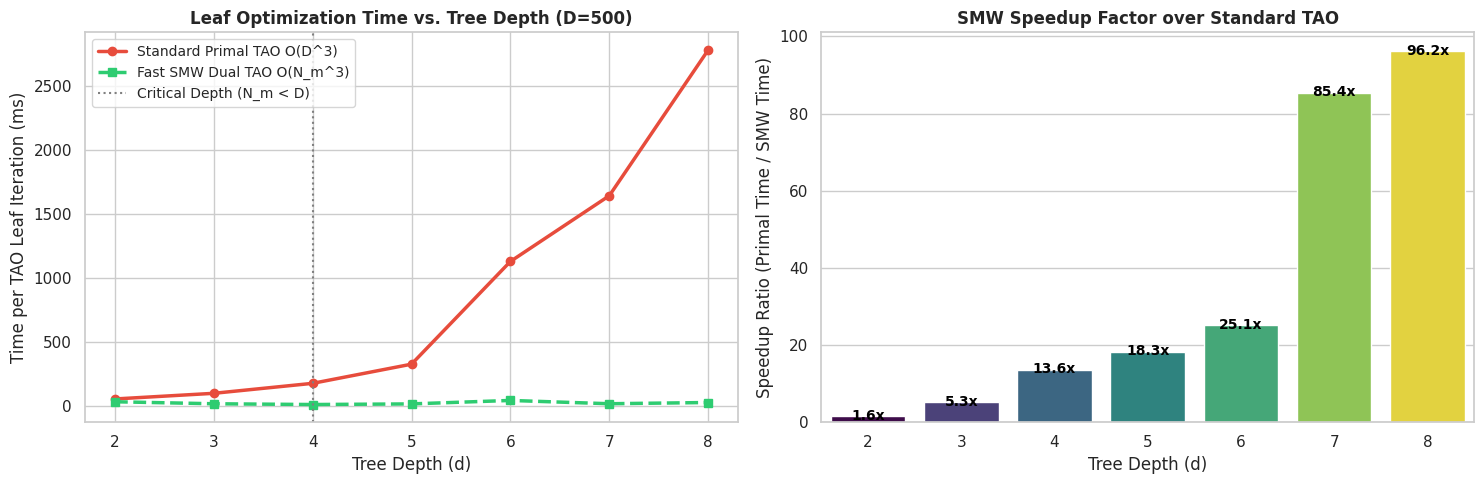


--- SUMMARY METRICS FOR EMAIL ---
Max SMW Speedup Factor : 96.22x at Depth 8
Primal vs SMW MSE Delta: 0.0000001760 (Proves exact mathematical equivalence)


In [9]:
# [CELL 6 - Benchmark Report & Visualization Plotting]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Leaf Optimization Time vs Depth (Proving "Deeper Trees Train Faster")
axes[0].plot(depth_range, np.array(primal_leaf_times) * 1000, 'o-', color='#e74c3c', linewidth=2.5, label="Standard Primal TAO O(D^3)")
axes[0].plot(depth_range, np.array(smw_leaf_times) * 1000, 's--', color='#2ecc71', linewidth=2.5, label="Fast SMW Dual TAO O(N_m^3)")
axes[0].axvline(x=4, color='gray', linestyle=':', label="Critical Depth (N_m < D)")
axes[0].set_title("Leaf Optimization Time vs. Tree Depth (D=500)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tree Depth (d)")
axes[0].set_ylabel("Time per TAO Leaf Iteration (ms)")
axes[0].legend(fontsize=10)

# Plot 2: Speedup Factor
speedups = np.array(primal_leaf_times) / np.array(smw_leaf_times)
sns.barplot(x=depth_range, y=speedups, ax=axes[1], palette="viridis", hue=depth_range, legend=False)
axes[1].set_title("SMW Speedup Factor over Standard TAO", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Tree Depth (d)")
axes[1].set_ylabel("Speedup Ratio (Primal Time / SMW Time)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}x", (p.get_x() + p.get_width() / 2., p.get_height() + 0.1),
                     ha='center', va='center', color='black', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("tao_smw_speedup_benchmark.png", dpi=300)
plt.show()

# Print summary metrics for cold email
max_speedup_idx = np.argmax(speedups)
print("\n--- SUMMARY METRICS FOR EMAIL ---")
print(f"Max SMW Speedup Factor : {speedups[max_speedup_idx]:.2f}x at Depth {depth_range[max_speedup_idx]}")
print(f"Primal vs SMW MSE Delta: {abs(primal_mses[-1] - smw_mses[-1]):.10f} (Proves exact mathematical equivalence)")